In [3]:
# src/ts_project/quick_test.py
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

dates = pd.date_range("2023-01-01", periods=100, freq="D")
df = pd.DataFrame({
    "unique_id": "series_1",
    "ds": dates,
    "y": np.sin(np.arange(100) / 5) * 10 + 50 + np.random.normal(0, 1, 100)
})

sf = StatsForecast(models=[AutoARIMA()], freq="D")
sf.fit(df)
forecast = sf.predict(h=14)
print(forecast)

   unique_id         ds  AutoARIMA
0   series_1 2023-04-11  60.296867
1   series_1 2023-04-12  60.476235
2   series_1 2023-04-13  60.381077
3   series_1 2023-04-14  59.818256
4   series_1 2023-04-15  58.922536
5   series_1 2023-04-16  57.594955
6   series_1 2023-04-17  56.063046
7   series_1 2023-04-18  54.315698
8   series_1 2023-04-19  52.442662
9   series_1 2023-04-20  50.540164
10  series_1 2023-04-21  48.691467
11  series_1 2023-04-22  46.955162
12  series_1 2023-04-23  45.413062
13  series_1 2023-04-24  44.120533


In [4]:
"""
Walk-Forward Vergleich von Forecasting-Modellen fuer META-Aktie.

Vergleicht:
    1. Naive (letzter bekannter Wert)
    2. AutoARIMA (statsforecast)
    3. LightGBM mit Feature-Engineering (Lags, Rolling Stats, RSI, MACD)

Metriken: MASE, sMAPE, Directional Accuracy
Output: Vergleichsplot + Metrik-Tabelle

Voraussetzungen (in deiner venv):
    uv pip install yfinance lightgbm statsforecast pandas numpy matplotlib scikit-learn
"""

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive

warnings.filterwarnings("ignore")

In [5]:
TICKER = "META"
START_DATE = "2019-01-01"
HORIZON = 5          # Vorhersage-Schritte pro Fenster
N_WINDOWS = 30        # Anzahl Walk-Forward Fenster
STEP_SIZE = 5         # Schrittweite zwischen Fenstern

In [6]:
# --------------------------------------------------------------------------
# 1. Daten laden
# --------------------------------------------------------------------------
def load_data(ticker: str, start: str) -> pd.DataFrame:
    raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)
    raw = raw[["Close", "Volume"]].reset_index()
    raw.columns = ["ds", "y", "volume"]
    raw["unique_id"] = ticker
    return raw[["unique_id", "ds", "y", "volume"]]

In [7]:
# --------------------------------------------------------------------------
# 2. Feature Engineering (nur Vergangenheitsdaten, kein Leakage)
# --------------------------------------------------------------------------
def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("ds").copy()

    for lag in [1, 2, 3, 5, 10]:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    df["roll_mean_5"] = df["y"].shift(1).rolling(5).mean()
    df["roll_std_5"] = df["y"].shift(1).rolling(5).std()
    df["roll_mean_20"] = df["y"].shift(1).rolling(20).mean()

    ema12 = df["y"].shift(1).ewm(span=12, adjust=False).mean()
    ema26 = df["y"].shift(1).ewm(span=26, adjust=False).mean()
    df["macd"] = ema12 - ema26

    df["rsi_14"] = compute_rsi(df["y"].shift(1), 14)

    df["volume_change"] = df["volume"].shift(1).pct_change()
    df["day_of_week"] = df["ds"].dt.dayofweek

    df["y_return"] = df["y"].pct_change()

    return df.dropna().reset_index(drop=True)

In [8]:
# --------------------------------------------------------------------------
# 3. Metriken
# --------------------------------------------------------------------------
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom)) * 100


def mase(y_true, y_pred, y_train):
    naive_diff = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / (naive_diff + 1e-9)


def directional_accuracy(y_true_prev, y_true, y_pred):
    true_dir = np.sign(y_true - y_true_prev)
    pred_dir = np.sign(y_pred - y_true_prev)
    return np.mean(true_dir == pred_dir) * 100

In [9]:
# --------------------------------------------------------------------------
# 4. Walk-Forward Vergleich
# --------------------------------------------------------------------------
def walk_forward_evaluate(df_raw: pd.DataFrame, df_feat: pd.DataFrame):
    feature_cols = [c for c in df_feat.columns
                    if c not in ["unique_id", "ds", "y", "volume", "y_return"]]

    results = {"naive": [], "arima": [], "lgbm": []}
    n = len(df_feat)
    start_idx = n - N_WINDOWS * STEP_SIZE - HORIZON

    for w in range(N_WINDOWS):
        train_end = start_idx + w * STEP_SIZE
        test_start, test_end = train_end, train_end + HORIZON
        if test_end > n:
            break

        train_feat = df_feat.iloc[:train_end]
        test_feat = df_feat.iloc[test_start:test_end]
        if len(train_feat) < 60 or len(test_feat) == 0:
            continue

        y_train = train_feat["y"].values
        y_test = test_feat["y"].values
        y_last_known = y_train[-1]

        # --- Naive ---
        naive_pred = np.repeat(y_last_known, len(y_test))

        # --- AutoARIMA (statsforecast) ---
        sf_train = train_feat[["unique_id", "ds", "y"]]
        sf = StatsForecast(models=[AutoARIMA(season_length=5)], freq="B")
        sf.fit(sf_train)
        arima_fc = sf.predict(h=len(y_test))
        arima_pred = arima_fc["AutoARIMA"].values

        # --- LightGBM ---
        X_train, y_train_lgb = train_feat[feature_cols], train_feat["y"]
        X_test = test_feat[feature_cols]
        model = lgb.LGBMRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.05, verbosity=-1
        )
        model.fit(X_train, y_train_lgb)
        lgbm_pred = model.predict(X_test)

        for name, pred in [("naive", naive_pred), ("arima", arima_pred), ("lgbm", lgbm_pred)]:
            results[name].append({
                "y_true": y_test,
                "y_pred": pred,
                "y_train": y_train,
                "y_last_known": y_last_known,
            })

    return results, feature_cols


def summarize_results(results: dict) -> pd.DataFrame:
    rows = []
    for model_name, windows in results.items():
        all_true = np.concatenate([w["y_true"] for w in windows])
        all_pred = np.concatenate([w["y_pred"] for w in windows])
        all_train = windows[0]["y_train"]

        prev_vals = np.concatenate([
            np.repeat(w["y_last_known"], len(w["y_true"])) for w in windows
        ])

        rows.append({
            "model": model_name,
            "sMAPE (%)": round(smape(all_true, all_pred), 3),
            "MASE": round(mase(all_true, all_pred, all_train), 3),
            "Directional Accuracy (%)": round(
                directional_accuracy(prev_vals, all_true, all_pred), 2
            ),
        })
    return pd.DataFrame(rows).sort_values("MASE")

In [10]:
# --------------------------------------------------------------------------
# 5. Plot
# --------------------------------------------------------------------------
def plot_last_window(df_feat: pd.DataFrame, results: dict, save_path: str):
    last = {name: windows[-1] for name, windows in results.items()}
    n_h = len(last["naive"]["y_true"])
    x = np.arange(n_h)

    plt.figure(figsize=(10, 5))
    plt.plot(x, last["naive"]["y_true"], "o-", label="Tatsaechlich", color="black", linewidth=2)
    plt.plot(x, last["naive"]["y_pred"], "--", label="Naive")
    plt.plot(x, last["arima"]["y_pred"], "--", label="AutoARIMA")
    plt.plot(x, last["lgbm"]["y_pred"], "--", label="LightGBM")
    plt.title(f"{TICKER}: Vorhersagevergleich letztes Testfenster")
    plt.xlabel("Handelstage")
    plt.ylabel("Preis (USD)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Plot gespeichert unter: {save_path}")

In [11]:
# --------------------------------------------------------------------------
# main
# --------------------------------------------------------------------------
def main():
    print(f"Lade Daten fuer {TICKER}...")
    df_raw = load_data(TICKER, START_DATE)
    print(f"{len(df_raw)} Handelstage geladen.")

    df_feat = build_features(df_raw)
    print(f"Feature-Set: {len(df_feat)} Zeilen nach Bereinigung.")

    print(f"Starte Walk-Forward-Evaluation ({N_WINDOWS} Fenster, Horizon={HORIZON})...")
    results, feature_cols = walk_forward_evaluate(df_raw, df_feat)

    summary = summarize_results(results)
    print("\n=== Ergebnisse ===")
    print(summary.to_string(index=False))

    plot_last_window(df_feat, results, "meta_forecast_comparison.png")



Lade Daten fuer META...
1890 Handelstage geladen.
Feature-Set: 1870 Zeilen nach Bereinigung.
Starte Walk-Forward-Evaluation (30 Fenster, Horizon=5)...

=== Ergebnisse ===
model  sMAPE (%)  MASE  Directional Accuracy (%)
 lgbm      2.085 2.430                     73.33
naive      3.172 3.652                      0.00
arima      3.179 3.660                     52.00
Plot gespeichert unter: meta_forecast_comparison.png


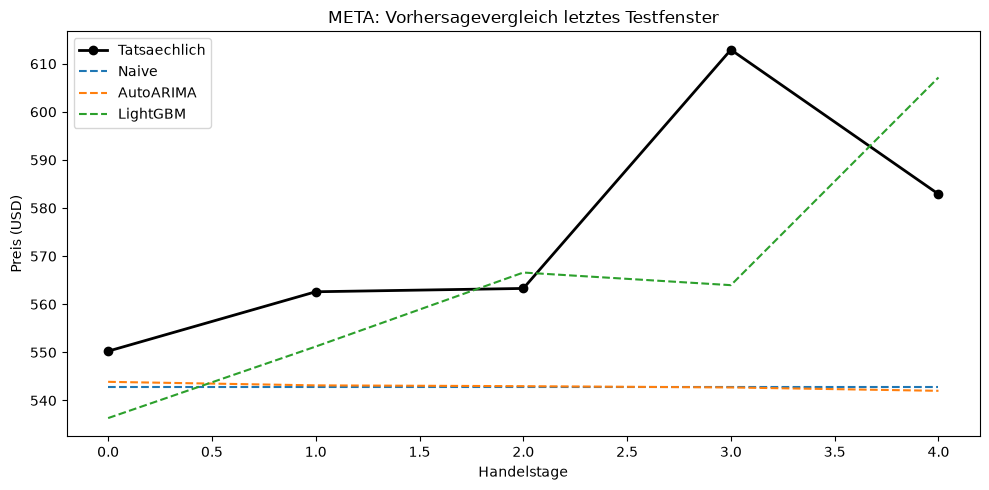

In [12]:

if __name__ == "__main__":
    main()